# Mosaic `USWEST_domainMask_v1_4326` shards

This notebook finds all GeoTIFF shards matching the exported GEE prefix, verifies that their CRS / resolution / datatype / band count agree, and mosaics them into one GeoTIFF without loading the entire western-US raster into memory.

**Mask semantics:** `0 = excluded`, `1 = retained`.

In [1]:
from pathlib import Path
import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling

# Any one shard can be used to identify the directory + filename prefix.
first_shard = Path(
    r"D:\My Drive\USWEST_domainMask_v1_4326-0000000000-0000000000.tif"
)

shard_dir = first_shard.parent
prefix = "USWEST_domainMask_v1_4326-"
output_path = Path(r"A:\NCA_DATA\templates\USWEST_domainMask_v1_4326.tif")
shards = sorted(shard_dir.glob(f"{prefix}*.tif"))

print(f"Found {len(shards)} shards")
print(f"Output: {output_path}")

if not shards:
    raise FileNotFoundError(
        f"No shards found in {shard_dir} matching {prefix}*.tif"
    )

Found 16 shards
Output: A:\NCA_DATA\templates\USWEST_domainMask_v1_4326.tif


In [2]:
# Inspect and verify the shards before mosaicking.
records = []

for p in shards:
    with rasterio.open(p) as src:
        records.append({
            "name": p.name,
            "crs": str(src.crs),
            "res": src.res,
            "dtype": src.dtypes[0],
            "count": src.count,
            "nodata": src.nodata,
            "width": src.width,
            "height": src.height,
            "bounds": src.bounds,
        })

reference = records[0]

for r in records[1:]:
    assert r["crs"] == reference["crs"], (
        f"CRS mismatch: {r['name']} has {r['crs']} "
        f"instead of {reference['crs']}"
    )
    assert r["res"] == reference["res"], (
        f"Resolution mismatch: {r['name']} has {r['res']} "
        f"instead of {reference['res']}"
    )
    assert r["dtype"] == reference["dtype"], (
        f"Dtype mismatch: {r['name']} has {r['dtype']} "
        f"instead of {reference['dtype']}"
    )
    assert r["count"] == reference["count"], (
        f"Band-count mismatch: {r['name']} has {r['count']} "
        f"instead of {reference['count']}"
    )

print("Shard checks passed.")
print(f"CRS:        {reference['crs']}")
print(f"Resolution: {reference['res']}")
print(f"Dtype:      {reference['dtype']}")
print(f"Bands:      {reference['count']}")
print(f"Nodata:     {reference['nodata']}")

Shard checks passed.
CRS:        GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Dtype:      uint8
Bands:      1
Nodata:     None


In [3]:
# Mosaic directly to disk.
#
# mem_limit keeps rasterio from constructing the entire western-US
# raster in RAM. Nearest-neighbor is appropriate for this categorical
# binary mask.

srcs = [rasterio.open(p) for p in shards]

try:
    merge(
        srcs,
        dst_path=output_path,
        method="first",
        resampling=Resampling.nearest,
        target_aligned_pixels=True,
        mem_limit=512,   # MB
        dst_kwds={
            "driver": "GTiff",
            "compress": "DEFLATE",
            "predictor": 2,
            "tiled": True,
            "blockxsize": 512,
            "blockysize": 512,
            "BIGTIFF": "IF_SAFER",
        },
    )
finally:
    for src in srcs:
        src.close()

print(f"Wrote mosaic:\n{output_path}")

Wrote mosaic:
A:\NCA_DATA\templates\USWEST_domainMask_v1_4326.tif


In [4]:
# Final QA: inspect metadata and confirm that the mask remains binary.
# Reading at reduced resolution avoids pulling the whole raster into RAM.

import numpy as np

with rasterio.open(output_path) as src:
    print("CRS:", src.crs)
    print("Size:", src.width, "x", src.height)
    print("Resolution:", src.res)
    print("Dtype:", src.dtypes)
    print("Nodata:", src.nodata)
    print("Bounds:", src.bounds)

    scale = max(src.width, src.height) / 4000
    if scale < 1:
        scale = 1

    out_h = max(1, int(src.height / scale))
    out_w = max(1, int(src.width / scale))

    sample = src.read(
        1,
        out_shape=(out_h, out_w),
        resampling=Resampling.nearest
    )

    vals = np.unique(sample)
    print("Unique values in reduced-resolution QA sample:", vals)

    unexpected = vals[~np.isin(vals, [0, 1])]
    if len(unexpected):
        print("WARNING: unexpected sampled values:", unexpected)
    else:
        print("Binary 0/1 QA passed on the reduced-resolution sample.")

CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Size: 253893 x 196707
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Dtype: ('uint8',)
Nodata: None
Bounds: BoundingBox(left=-124.84902599680045, bottom=31.332069300219555, right=-102.04142975370468, top=49.00255975954943)
Unique values in reduced-resolution QA sample: [0 1]
Binary 0/1 QA passed on the reduced-resolution sample.


Display raster shape: (2324, 3000)


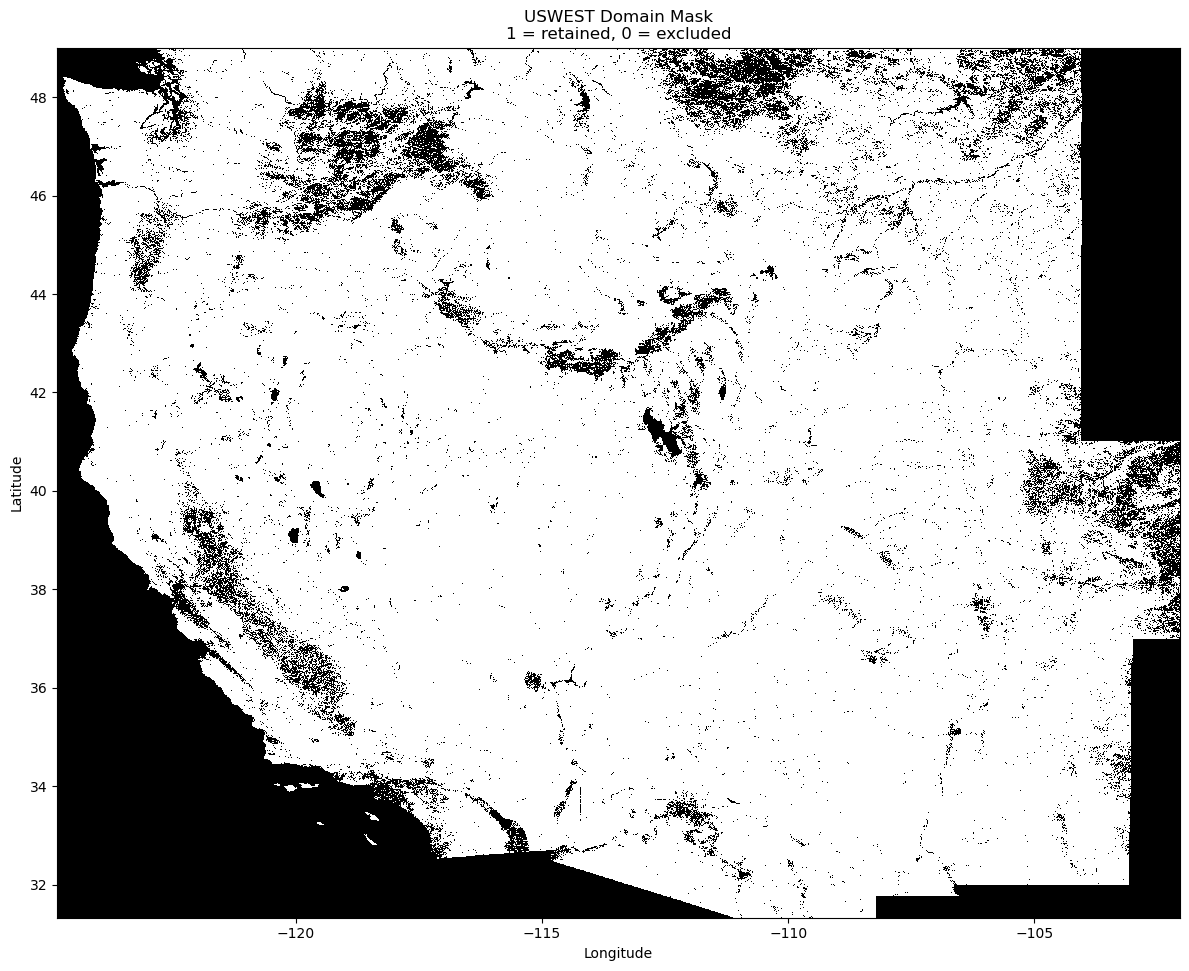

In [5]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

raster_path = r"A:\NCA_DATA\templates\USWEST_domainMask_v1_4326.tif"

# Target display size. This preserves the full spatial extent
# while avoiding loading the enormous native-resolution raster.
max_display_dim = 3000

with rasterio.open(raster_path) as src:
    
    scale = max(src.width, src.height) / max_display_dim
    
    out_width = max(1, int(src.width / scale))
    out_height = max(1, int(src.height / scale))
    
    mask = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.nearest
    )
    
    bounds = src.bounds

print("Display raster shape:", mask.shape)

plt.figure(figsize=(12, 10))

plt.imshow(
    mask,
    extent=[
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top
    ],
    origin="upper",
    interpolation="nearest",
    cmap="gray"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("USWEST Domain Mask\n1 = retained, 0 = excluded")

plt.tight_layout()
plt.show()